---
title: xarray EOPF backend - Sentinel-2 Native mode
subtitle: Learn how to access Sentinel-2 products in native mode
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-03-27
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-2", "xarray-eopf", "land"]
releaseDate: 2026-03-27
datePublished: 2026-03-27
dateModified: 2026-03-27
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XEOPF_SEN2_NATIVE)
2. [Import modules](#Import_XEOPF_SEN2_NATIVE)
3. [Open a Sentinel-2 Level-1C](#Open_L1C_XEOPF_SEN2_NATIVE)
4. [Open a Sentinel-2 Level-2A](#Open_L2A_XEOPF_SEN2_NATIVE)
5. [Conclusion](#Conclusion_XEOPF_SEN2_NATIVE)

(Introduction_XEOPF_SEN2_NATIVE)=
## Introduction

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-2** EOPF Zarr products in **native mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage. 

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).

- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

:::{hint} Overview
**Questions**
- How can I use the xarray-eopf backend for Sentinel-2 in native mode?
- What main features does the xarray-eopf backend provide for Sentinel-2 in native mode?

**Objectives**
- Learn how to open Sentinel-2 EOPF Zarr products using `xarray-eopf`.
- Understand the key features and capabilities of the `xarray-eopf` backend in native mode for Sentinel-2.
:::

---

(Import_XEOPF_SEN2_NATIVE)=
## Import Modules

The `xarray-eopf` backend is implemented as a plugin for `xarray`. Once installed, it registers automatically and requires no additional import. You can simply import `xarray` as usual:

In [1]:
import datetime

import matplotlib.pyplot as plt
import pystac_client
import xarray as xr

---

(Open_L1C_XEOPF_SEN2_NATIVE)=
## Open a Sentinel-2 Level-1C 

We begin with an example that accesses a Sentinel-2 Level-1C product in **native mode**. 

### Find a Sentinel-2 Level-1C Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-2-l1c) to search for a Sentinel-2 Level-1C tile. Here, the `query` parameter is used to select tiles with less than 40% cloud cover, improving the chances of a clear plot.

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-2-l1c"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=30)), None],
        query={"eo:cloud_cover": {"lt": 40}},
    ).items()
)
items

[<Item id=S2A_MSIL1C_20260326T102701_N0512_R108_T32TLQ_20260326T154418>,
 <Item id=S2C_MSIL1C_20260321T101721_N0512_R065_T32TLQ_20260321T143127>,
 <Item id=S2B_MSIL1C_20260319T103019_N0512_R108_T32TLQ_20260319T145744>,
 <Item id=S2A_MSIL1C_20260316T103041_N0512_R108_T32TLQ_20260316T172545>,
 <Item id=S2B_MSIL1C_20260316T101649_N0512_R065_T32TLQ_20260316T153332>,
 <Item id=S2A_MSIL1C_20260313T101741_N0512_R065_T32TLQ_20260313T153853>,
 <Item id=S2C_MSIL1C_20260304T102921_N0512_R108_T32TLQ_20260304T140806>]

Next, we can inspect the item’s contents. The asset `"product"` links to the entire Zarr store. The additional field `xarray:open_datatree_kwargs` has been included in the asset `"product"`, which provides the arguments needed to open the product using Xarray’s `eopf-zarr` engine.

In [3]:
item = items[0]
item

<Item id=S2A_MSIL1C_20260326T102701_N0512_R108_T32TLQ_20260326T154418>

### Open Sentinel-2 Level-1C as `xarray.DataTree`

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [4]:
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
)
dt

<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:                        (angle: 2, band: 13, y: 23, x: 23,
│   │                                           detector: 7)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b01' 'b02' ... 'b11' 'b12'
│   │         * y                              (y) float32 92B 5e+06 4.995e+06 ... 4.89e+06
│   │         * x                              (x) float32 92B 3e+05 3.05e+05 ... 4.1e+05
│   │         * detector                       (detector) <U3 84B 'd06' 'd07' ... 'd12'
│   │       Data variables:
│   │           mean_sun_angles                (angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
│   │           mean_viewing_incidence_angles  (band, angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
│   │           sun_angles                     (angle, y, x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
│   │           viewing_incidence_angles       (band, detector, angle, y, x) float64 770kB dask.array<chunksize=(13, 7, 2, 23, 23), meta=np.ndarray>
│   ├── Group: /conditions/mask
│   │   ├── Group: /conditions/mask/detector_footprint
│   │   │   ├── Group: /conditions/mask/detector_footprint/r10m
│   │   │   │       Dimensions:  (y: 10980, x: 10980)
│   │   │   │       Coordinates:
│   │   │   │         * y        (y) float32 44kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │   │         * x        (x) float32 44kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
│   │   │   │       Data variables:
│   │   │   │           b02      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b03      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b04      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b08      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   ├── Group: /conditions/mask/detector_footprint/r20m
│   │   │   │       Dimensions:  (y: 5490, x: 5490)
│   │   │   │       Coordinates:
│   │   │   │         * y        (y) float32 22kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │   │         * x        (x) float32 22kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
│   │   │   │       Data variables:
│   │   │   │           b05      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b06      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b07      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b11      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b12      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b8a      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   └── Group: /conditions/mask/detector_footprint/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │   │           Coordinates:
│   │   │             * y        (y) float32 7kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │             * x        (x) float32 7kB 3e+05 3.001e+05 3.002e+05 ... 4.097e+05 4.098e+05
│   │   │           Data variables:
│   │   │               b01      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b09      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b10      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   └── Group: /conditions/mask/l1c_classification
│   │       └── Group: /conditions/mask/l1c_classification/r60m
│   │               Dimensions:  (y: 1830, x: 1830)
│   │   

As an example, we plot the spectral band 9 (`b09`) at 60 meters resolution, which will trigger loading and visualization of the data. Additionally, we will plot the viewing and solar zenith angle on the side.  

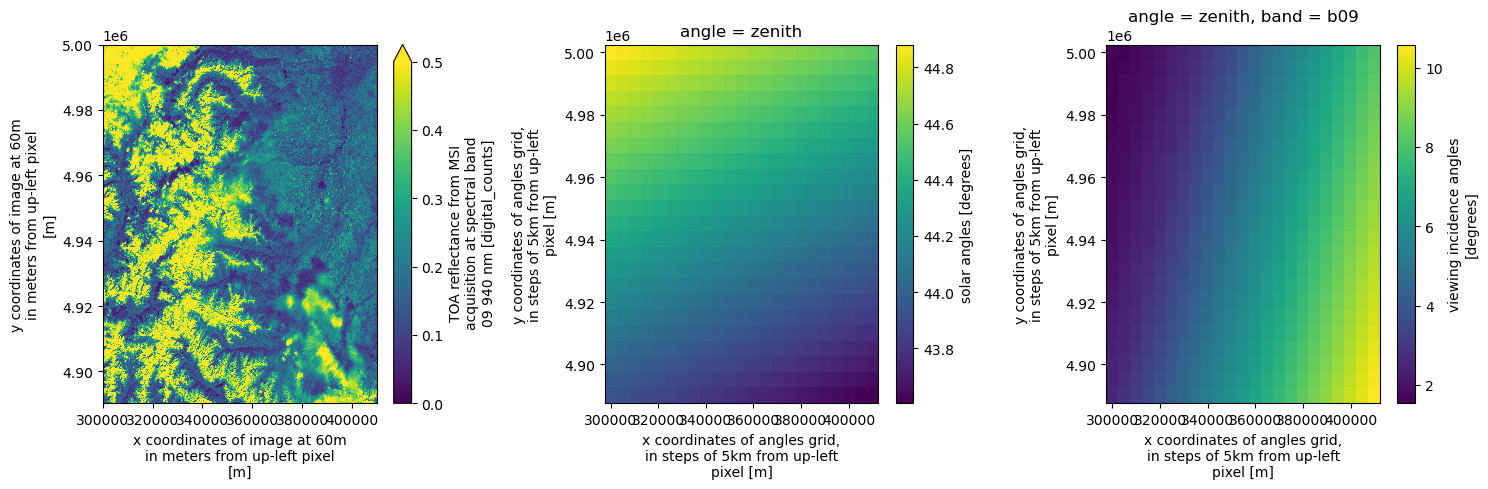

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
dt.measurements.reflectance.r60m.b09.plot.imshow(ax=ax[0], vmin=0, vmax=0.5)
dt.conditions.geometry.sun_angles.sel(angle="zenith").plot.imshow(ax=ax[1])
dt.conditions.geometry.viewing_incidence_angles.sel(angle="zenith", band="b09").mean(
    dim="detector"
).plot.imshow(ax=ax[2])
plt.tight_layout()

### Open Sentinel-2 Level-1C Reflectance Groups as `xarray.Dataset`

Similarly, we can open the individual reflectance groups at 10 m (`SR_10m`), 20 m (`SR_20m`), and 60 m (`SR_60m`) resolution as `xarray.Dataset` objects.  

The opening parameters are stored in the asset’s extra field `"xarray:open_dataset_kwargs"`. Note that when opening a group, only the bands available at that resolution (e.g., 10 m) are included.

In [6]:
ds = xr.open_dataset(
    item.assets["SR_10m"].href,
    **item.assets["SR_10m"].extra_fields["xarray:open_dataset_kwargs"],
)
ds

<xarray.Dataset> Size: 4GB
Dimensions:  (y: 10980, x: 10980)
Coordinates:
  * y        (y) float32 44kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
  * x        (x) float32 44kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
Data variables:
    b02      (y, x) float64 964MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    b03      (y, x) float64 964MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    b04      (y, x) float64 964MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    b08      (y, x) float64 964MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

We can also filter the varaibles by band names as shown below: 

In [7]:
ds = xr.open_dataset(
    item.assets["SR_10m"].href,
    **item.assets["SR_10m"].extra_fields["xarray:open_dataset_kwargs"],
    variables="b0[234]",
)
ds

<xarray.Dataset> Size: 3GB
Dimensions:  (y: 10980, x: 10980)
Coordinates:
  * y        (y) float32 44kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
  * x        (x) float32 44kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
Data variables:
    b02      (y, x) float64 964MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    b03      (y, x) float64 964MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    b04      (y, x) float64 964MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

And we can plot a cutout of the RGB image, which triggers loading the data.

In [8]:
array = ds[["b04", "b03", "b02"]].to_dataarray(dim="band")
array = array.isel(x=slice(-1830, None), y=slice(-1830, None))
array

<xarray.DataArray (band: 3, y: 1830, x: 1830)> Size: 80MB
dask.array<getitem, shape=(3, 1830, 1830), dtype=float64, chunksize=(1, 1090, 1090), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 24B 'b04' 'b03' 'b02'
  * y        (y) float32 7kB 4.909e+06 4.909e+06 4.909e+06 ... 4.89e+06 4.89e+06
  * x        (x) float32 7kB 3.915e+05 3.915e+05 ... 4.098e+05 4.098e+05

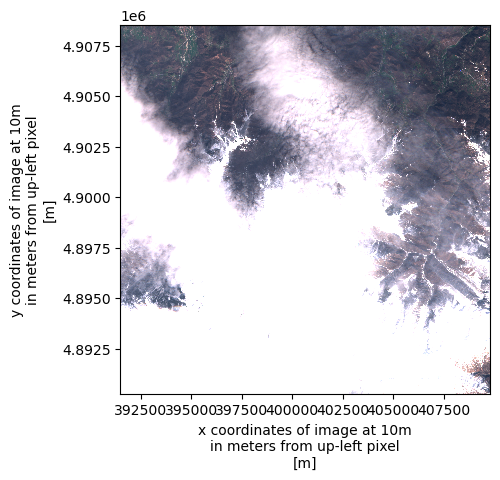

In [9]:
ax = (array / 0.3).clip(0, 1).plot.imshow(rgb="band")
ax.axes.set_aspect("equal")

### Open Sentinel-2 Level-1C as `xarray.Dataset`

The `xarray.DataTree` model was introduced in xarray v2024.10.0 (October 2024). To maintain compatibility with workflows based on `xr.Dataset`, the function `xarray.open_dataset(..., engine="eopf-zarr", op_mode="native")` is provided, which flattens the `DataTree` into a single dataset.

During this process, hierarchical groups in the Zarr product are merged, and variable as well as dimension names are prefixed with their group paths (using `_` by default) to ensure uniqueness. For example, `measurements/reflectance/r10m/b02` becomes `measurements_reflectance_r10m_b02`.


In [10]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
)
ds

<xarray.Dataset> Size: 7GB
Dimensions:                                            (
                                                        conditions_geometry_angle: 2,
                                                        conditions_geometry_band: 13,
                                                        conditions_geometry_y: 23,
                                                        conditions_geometry_x: 23,
                                                        conditions_geometry_detector: 7,
                                                        ...
                                                        quality_r10m_y: 10980,
                                                        quality_r10m_x: 10980,
                                                        quality_r20m_y: 5490,
                                                        quality_r20m_x: 5490,
                                                        quality_r60m_y: 1830,
                                                        quality_r60m_x: 1830)
Coordinates: (12/29)
  * conditions_geometry_angle                          (conditions_geometry_angle) <U7 56B ...
  * conditions_geometry_band                           (conditions_geometry_band) <U3 156B ...
  * conditions_geometry_y                              (conditions_geometry_y) float32 92B ...
  * conditions_geometry_x                              (conditions_geometry_x) float32 92B ...
  * conditions_geometry_detector                       (conditions_geometry_detector) <U3 84B ...
  * conditions_mask_detector_footprint_r10m_y          (conditions_mask_detector_footprint_r10m_y) float32 44kB ...
    ...                                                 ...
  * quality_r10m_y                                     (quality_r10m_y) float32 44kB ...
  * quality_r10m_x                                     (quality_r10m_x) float32 44kB ...
  * quality_r20m_y                                     (quality_r20m_y) float32 22kB ...
  * quality_r20m_x                                     (quality_r20m_x) float32 22kB ...
  * quality_r60m_y                                     (quality_r60m_y) float32 7kB ...
  * quality_r60m_x                                     (quality_r60m_x) float32 7kB ...
Data variables: (12/61)
    conditions_geometry_mean_sun_angles                (conditions_geometry_angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    conditions_geometry_mean_viewing_incidence_angles  (conditions_geometry_band, conditions_geometry_angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
    conditions_geometry_sun_angles                     (conditions_geometry_angle, conditions_geometry_y, conditions_geometry_x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
    conditions_geometry_viewing_incidence_angles       (conditions_geometry_band, conditions_geometry_detector, conditions_geometry_angle, conditions_geometry_y, conditions_geometry_x) float64 770kB dask.array<chunksize=(13, 7, 2, 23, 23), meta=np.ndarray>
    conditions_mask_detector_footprint_r10m_b02        (conditions_mask_detector_footprint_r10m_y, conditions_mask_detector_footprint_r10m_x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
    conditions_mask_detector_footprint_r10m_b03        (conditions_mask_detector_footprint_r10m_y, conditions_mask_detector_footprint_r10m_x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
    ...                                                 ...
    quality_r20m_b11                                   (quality_r20m_y, quality_r20m_x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    quality_r20m_b12                                   (quality_r20m_y, quality_r20m_x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    quality_r20m_b8a                                   (quality_r20m_y, quality_r20m_x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    quality_r60m_b01                      

The separator character used in flattened variable names can be customized via the `group_sep` parameter. Additionally, you can filter the returned variables using the `variables` keyword argument, which accepts a string, an iterable of names, or a regular expression (regex) pattern.

In [11]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
    group_sep="/",
    variables=["measurements/r60m/b09", "measurements/r60m/b10"],
)
ds

<xarray.Dataset> Size: 54MB
Dimensions:                (measurements/r60m/y: 1830, measurements/r60m/x: 1830)
Coordinates:
  * measurements/r60m/y    (measurements/r60m/y) float32 7kB 5e+06 ... 4.89e+06
  * measurements/r60m/x    (measurements/r60m/x) float32 7kB 3e+05 ... 4.098e+05
Data variables:
    measurements/r60m/b09  (measurements/r60m/y, measurements/r60m/x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    measurements/r60m/b10  (measurements/r60m/y, measurements/r60m/x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (3)

Also here, we can plot one spectral band as an example.

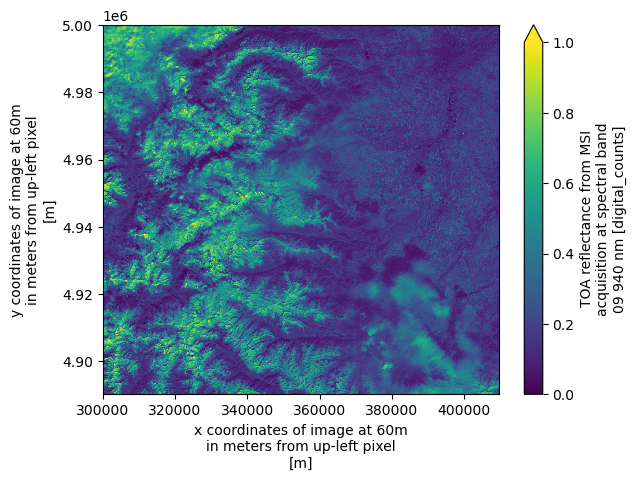

In [12]:
ds["measurements/r60m/b09"].plot(vmin=0.0, vmax=1.0)

---

(Open_L2A_XEOPF_SEN2_NATIVE)=
## Open a Sentinel-2 Level-2A

We now access a Sentinel-2 Level-2A product in **native mode**. The data access methods shown above apply equally to Level-2A products.

### Find a Sentinel-2 Level-2A Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-2-l2a) to search for available Sentinel-2 Level-2A tiles. Also here, the `query` parameter is used to select tiles with less than 40% cloud cover, improving the chances of a clear plot.

In [13]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=30)), None],
        query={"eo:cloud_cover": {"lt": 40}},
    ).items()
)
items

[<Item id=S2A_MSIL2A_20260326T102701_N0512_R108_T32TLQ_20260326T172711>,
 <Item id=S2B_MSIL2A_20260326T102019_N0512_R065_T32TLQ_20260326T155529>,
 <Item id=S2B_MSIL2A_20260319T103019_N0512_R108_T32TLQ_20260319T151320>,
 <Item id=S2A_MSIL2A_20260316T103041_N0512_R108_T32TLQ_20260316T184508>,
 <Item id=S2B_MSIL2A_20260316T101649_N0512_R065_T32TLQ_20260316T155405>,
 <Item id=S2A_MSIL2A_20260313T101741_N0512_R065_T32TLQ_20260313T171916>,
 <Item id=S2C_MSIL2A_20260304T102921_N0512_R108_T32TLQ_20260304T160811>]

In [14]:
item = items[0]
item

<Item id=S2A_MSIL2A_20260326T102701_N0512_R108_T32TLQ_20260326T172711>

### Open Sentinel-2 Level-2A as `xarray.DataTree`

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [15]:
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
)
dt

<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:                        (angle: 2, band: 13, y: 23, x: 23,
│   │                                           detector: 7)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b01' 'b02' ... 'b11' 'b12'
│   │         * y                              (y) float32 92B 5e+06 4.995e+06 ... 4.89e+06
│   │         * x                              (x) float32 92B 3e+05 3.05e+05 ... 4.1e+05
│   │         * detector                       (detector) object 56B 'd06' 'd07' ... 'd12'
│   │       Data variables:
│   │           mean_sun_angles                (angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
│   │           mean_viewing_incidence_angles  (band, angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
│   │           sun_angles                     (angle, y, x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
│   │           viewing_incidence_angles       (band, detector, angle, y, x) float64 770kB dask.array<chunksize=(13, 7, 2, 23, 23), meta=np.ndarray>
│   ├── Group: /conditions/mask
│   │   ├── Group: /conditions/mask/detector_footprint
│   │   │   ├── Group: /conditions/mask/detector_footprint/r10m
│   │   │   │       Dimensions:  (y: 10980, x: 10980)
│   │   │   │       Coordinates:
│   │   │   │         * y        (y) float32 44kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │   │         * x        (x) float32 44kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
│   │   │   │       Data variables:
│   │   │   │           b02      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b03      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b04      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b08      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   ├── Group: /conditions/mask/detector_footprint/r20m
│   │   │   │       Dimensions:  (y: 5490, x: 5490)
│   │   │   │       Coordinates:
│   │   │   │         * y        (y) float32 22kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │   │         * x        (x) float32 22kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
│   │   │   │       Data variables:
│   │   │   │           b05      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b06      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b07      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b11      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b12      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b8a      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   └── Group: /conditions/mask/detector_footprint/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │   │           Coordinates:
│   │   │             * y        (y) float32 7kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │             * x        (x) float32 7kB 3e+05 3.001e+05 3.002e+05 ... 4.097e+05 4.098e+05
│   │   │           Data variables:
│   │   │               b01      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b09      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b10      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   ├── Group: /conditions/mask/l1c_classification
│   │   │   └── Group: /conditions/mask/l1c_classification/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │

We can plot the RGB image, the SCL (Scene Classification Layer), the AOT (Aerosol Optical Thickness) map, and the WVP (Water Vapor Content) map at 60 m resolution.

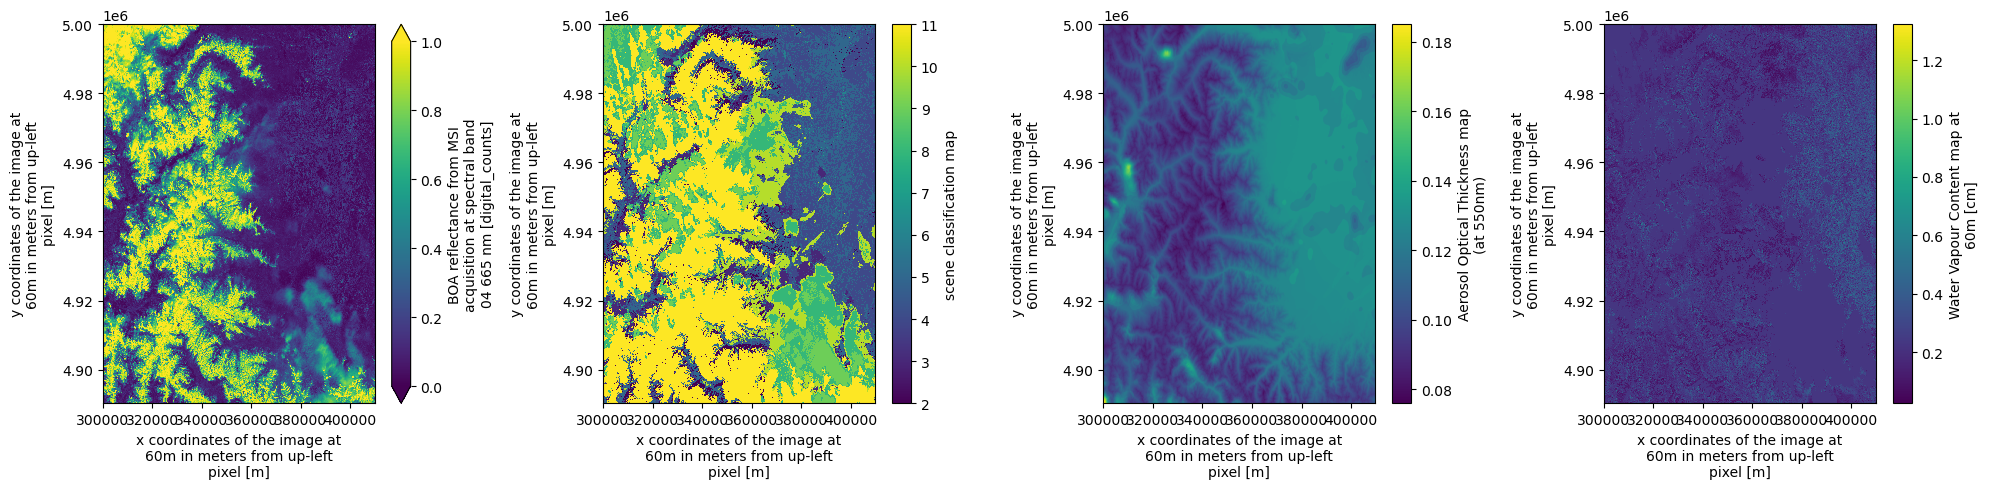

In [16]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
dt.measurements.reflectance.r60m.b04.plot.imshow(ax=ax[0], vmin=0.0, vmax=1.0)
dt.conditions.mask.l2a_classification.r60m.scl.plot.imshow(ax=ax[1])
dt.quality.atmosphere.r60m.aot.plot.imshow(ax=ax[2])
dt.quality.atmosphere.r60m.wvp.plot.imshow(ax=ax[3])
plt.tight_layout()

### Open Sentinel-2 Level-2A Reflectance Groups as `xarray.Dataset`

Similarly, we can open the individual reflectance groups at 10 m (`SR_10m`), 20 m (`SR_20m`), and 60 m (`SR_60m`) resolution as `xarray.Dataset` objects.  

The opening parameters are stored in the asset’s extra field `"xarray:open_dataset_kwargs"`. Note that in Level-2A, some of the native bands are resampled to coarser resoltion. This is idendical to the previous SAFE format. 

In [17]:
ds = xr.open_dataset(
    item.assets["SR_60m"].href,
    **item.assets["SR_60m"].extra_fields["xarray:open_dataset_kwargs"],
)
ds

<xarray.Dataset> Size: 295MB
Dimensions:  (y: 1830, x: 1830)
Coordinates:
  * y        (y) float32 7kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
  * x        (x) float32 7kB 3e+05 3.001e+05 3.002e+05 ... 4.097e+05 4.098e+05
Data variables:
    b01      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b02      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b04      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b05      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b06      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b07      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b11      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b12      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>

All other data access methods shown for Sentinel Level-1C products apply equally to Level-2A products.

---

(Conclusion_XEOPF_SEN2_NATIVE)=
## Conclusion

This notebook demonstrates how to access Sentinel-2 EOPF Zarr samples in **native mode** using the **xarray-eopf** plugin. Key takeaways are:

- Access Sentinel-2 Level-1C and Level-2A products.  
- Open the full Zarr store as an `xr.DataTree` using `xr.open_dataset` and the asset `"product"`.  
- Open subgroups (e.g., spectral reflectance at 10 m, 20 m, or 60 m) as `xr.Dataset` using `xr.open_dataset`.  
- Open the full Zarr store as a flattened `xr.Dataset` using `xr.open_dataset` and the asset `"product"`.  
- Filter variables using the `variables` keyword argument.
- Opening parameters are integrated in STAC assets.

> Note: This notebook only covers the **native mode**, which presents the data as close as possible to the original product.  
> For an **analysis-ready view**, see the [Sentinel-2 analysis mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_2_analysis/).

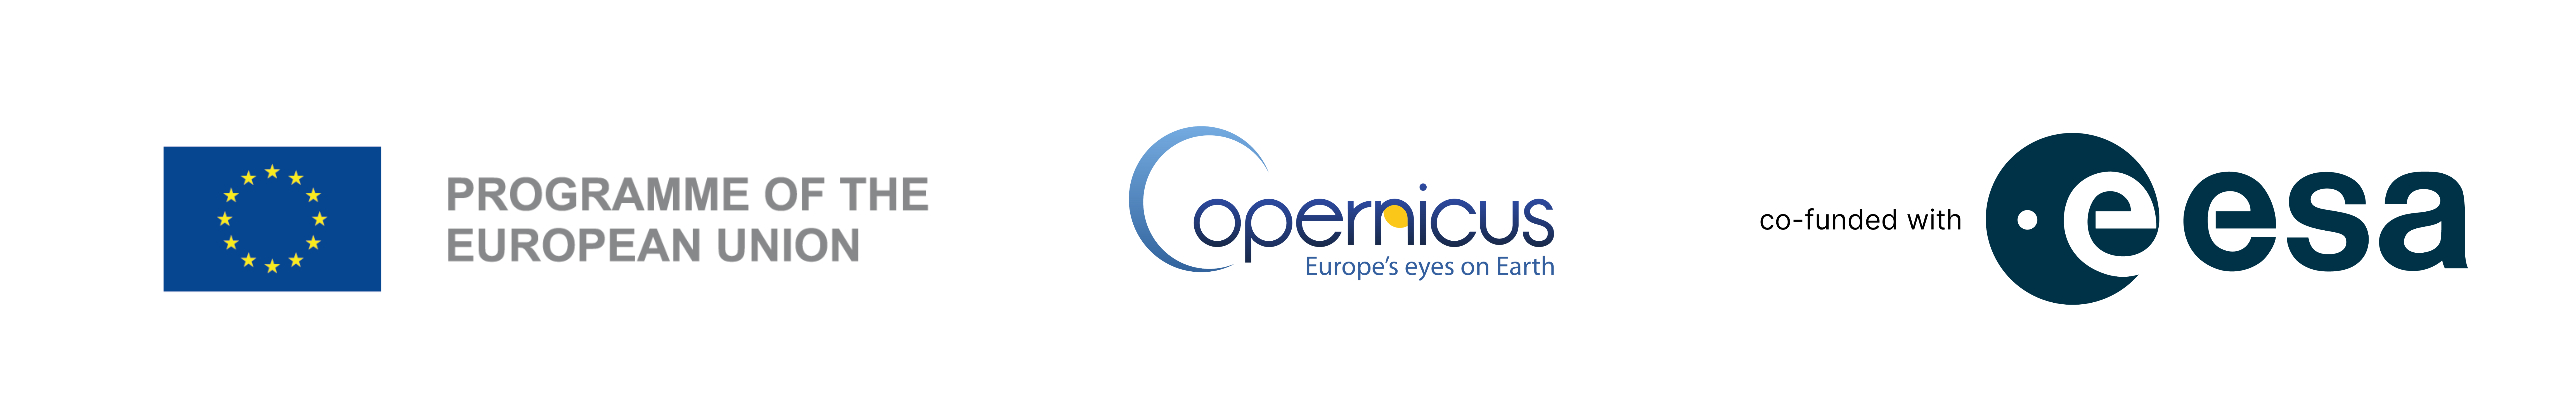